In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_csv("Saved Data/mcmc_cmb_chain.csv")

ell, cl_obs, dl_obs = np.loadtxt("Saved Data/APS_anafast.txt", skiprows=1, unpack=True)
ell = ell.astype(int)

d = df.shape[1] - 1        # every column except Chi_sq is a fitted parameter

LMIN, LMAX, DL_BIN = 30, 1000, 10                
F_SKY = 0.7780                                   # from np.mean(mask**2) in CMB_Planck.ipynb 

# group the multipoles into bands of width DL_BIN
edges   = np.arange(LMIN, LMAX + 1, DL_BIN)
bin_idx = [np.where((ell >= edges[b]) & (ell < edges[b+1]))[0] for b in range(len(edges) - 1)]

def bin_it(y):
    return np.array([y[i].mean() for i in bin_idx])

l_eff  = bin_it(ell.astype(float))
D_data = bin_it(dl_obs)

print(f"{len(l_eff)} bandpowers, from l = {l_eff[0]:.0f} to {l_eff[-1]:.0f}")

97 bandpowers, from l = 34 to 994


Dark energy  $\Omega_\Lambda$ = 0.6666 +/- 0.0298   (66.66 %)
Dark matter  $\Omega_c$      = 0.2823 +/- 0.0274   (28.23 %)
Baryons  $\Omega_b$          = 0.0496 +/- 0.0023   (4.96 %)
Neutrinos  $\Omega_\nu$      = 0.0015 +/- 0.0001   (0.15 %)

Total = 1.0000


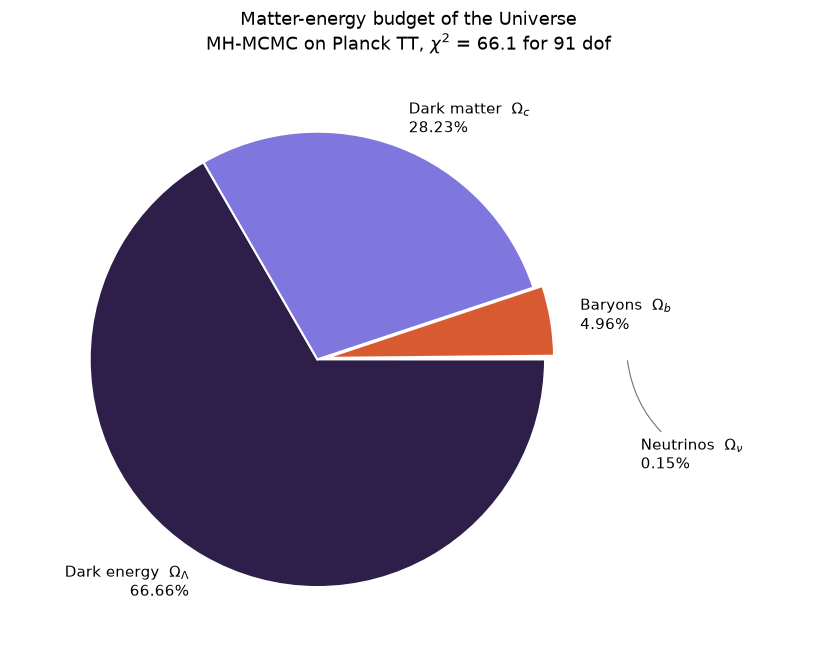

In [8]:
# --- Matter-energy budget of the Universe from the chain ---

h2    = (df['H0'] / 100)**2

Om_b  = df['ombh2'] / h2          # baryons
Om_c  = df['omch2'] / h2          # cold dark matter
Om_nu = (0.06 / 93.14) / h2               # massive neutrinos (mnu fixed at 0.06 eV in CAMB_DL)
Om_L  = 1 - (Om_b + Om_c + Om_nu)         # dark energy, from flatness (omk = 0)

comp        = [Om_L, Om_c, Om_b, Om_nu]
comp_names  = [r'Dark energy  $\Omega_\Lambda$', r'Dark matter  $\Omega_c$',
               r'Baryons  $\Omega_b$',           r'Neutrinos  $\Omega_\nu$']
colors      = ['#2E1F4A', '#7F77DD', '#D85A30', '#4CAF50']

frac = np.array([c.mean()        for c in comp])
err  = np.array([c.std(ddof=1)   for c in comp])

for nm, f, e in zip(comp_names, frac, err):
    print(f'{nm:28s} = {f:.4f} +/- {e:.4f}   ({100*f:.2f} %)')
print(f'\nTotal = {frac.sum():.4f}')

# percentages go in the labels -- the neutrino wedge is far too thin to write inside
pie_labels = [f'{nm}\n{100*f:.2f}%' for nm, f in zip(comp_names, frac)]

fig, ax = plt.subplots(figsize=(8.5, 6.5))

pie_labels = [f'{nm}\n{100*f:.2f}%' for nm, f in zip(comp_names, frac)]
pie_labels[-1] = ''                       # the sliver gets a leader line instead

wedges, texts = ax.pie(frac, labels=pie_labels, colors=colors,
                       startangle=0, counterclock=False,
                       explode=[0, 0, 0.04, 0.35],
                       labeldistance=1.13,
                       wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
                       textprops={'fontsize': 11})

# neutrinos are 0.15% -- too thin to label on the rim, so point at it from outside
w   = wedges[-1]
ang = np.radians(0.5 * (w.theta1 + w.theta2))
ax.annotate(f'{comp_names[-1]}\n{100*frac[-1]:.2f}%',
            xy=(1.36*np.cos(ang), 1.36*np.sin(ang)),
            xytext=(1.42, -0.42), ha='left', va='center', fontsize=11,
            arrowprops=dict(arrowstyle='-', lw=0.8, color='0.45',
                            connectionstyle='arc3,rad=-0.25'))

ax.set_xlim(-1.35, 2.15)                  # room on the right for the callout
ax.set_title('Matter-energy budget of the Universe\n'
             + r'MH-MCMC on Planck TT, $\chi^2$ = ' + f'{df["Chi_sq"].min():.1f} for 91 dof',
             fontsize=13, pad=18)
plt.tight_layout()
plt.show()